## 0. Imports e carregamento

> Certifique-se de ter rodado `02_nlp.ipynb` antes. Este notebook lê os dados já processados de `motor1_analise_final_clean.csv` e `tfidf_final_clean.csv`.

In [23]:
import json
import pathlib
import random
import re
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from joblib import Parallel, delayed
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from unidecode import unidecode

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
CORES = sns.color_palette("muted")

print("Imports OK")

Imports OK


In [24]:
import pandas as pd
import numpy as np
import pathlib
import scipy.sparse as sp
import seaborn as sns

# Os CSVs são gerados pelo 02_nlp.ipynb no diretório de trabalho.
# Se der FileNotFoundError, ajuste DATA_DIR para o caminho correto.
DATA_DIR = pathlib.Path.cwd()
print(f"Procurando CSVs em: {DATA_DIR}")

csv_principal = DATA_DIR / "motor1_analise_final_clean.csv"
csv_tfidf     = DATA_DIR / "tfidf_final_clean.csv"

if not csv_principal.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {csv_principal}\n"
        f"Certifique-se de ter rodado 02_nlp.ipynb neste mesmo diretório.\n"
        f"Se os arquivos estiverem em outro lugar, altere DATA_DIR acima."
    )

df       = pd.read_csv(csv_principal, encoding="utf-8-sig")
df_tfidf = pd.read_csv(csv_tfidf,     encoding="utf-8-sig")

vocab       = df_tfidf.columns.tolist()
X_tfidf_arr = df_tfidf.values
X           = X_tfidf_arr
X_tfidf     = sp.csr_matrix(X_tfidf_arr)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
CORES = sns.color_palette("muted")

print(f"Notícias carregadas : {len(df)}")
print(f"Features TF-IDF     : {len(vocab)}")
df.head(3)


Procurando CSVs em: c:\Users\muvil\Nova pasta\analise_site_motor1_uol
Notícias carregadas : 192
Features TF-IDF     : 653


,url,titulo,descricao,categoria,data,grupo,texto_limpo,n_tokens,n_unicos
0,https://motor1.uol.com.br/news/796755/novos-ri...,BYD Dolphin: os novos elétricos que podem amea...,"GAC, MG, DFM e Arcfox apostam em preço, autono...",Análise,2026-05-24T15:00:00+00:00,Elétrico,byd dolphin novos eletricos podem ameacar aind...,21,19
1,https://motor1.uol.com.br/news/796498/vendas-r...,Omoda 5 entra no top 10 britânico em mês de fo...,"Ford Puma lidera, mas o grande destaque do mer...",Análise,2026-05-24T12:00:00+00:00,Elétrico,omoda entra top britanico mes forte alta eletr...,18,16
2,https://motor1.uol.com.br/news/796725/citroen-...,O Citroën 2CV está quase pronto para voltar: e...,O lendário Citroën 2CV está de volta. Inspirad...,Análise,2026-05-23T15:00:00+00:00,Elétrico,citroen quase pronto voltar eis primeira image...,23,22


## 10. Classificação — Random Forest

In [25]:
le = LabelEncoder()
y = le.fit_transform(df["grupo"])
X = X_tfidf.toarray()

print("Classes:", le.classes_)
print("Distribuição:", dict(zip(le.classes_, np.bincount(y))))

contagem_y = np.bincount(y)
classes_validas = np.where(contagem_y >= 5)[0]
mask_valida = np.isin(y, classes_validas)

X_v = X[mask_valida]
y_v = y[mask_valida]

print(f"Amostras após filtro de classe mínima: {len(y_v)}")

Classes: ['Combustão' 'Elétrico' 'Geral' 'Misto/Híbrido']
Distribuição: {'Combustão': np.int64(10), 'Elétrico': np.int64(76), 'Geral': np.int64(95), 'Misto/Híbrido': np.int64(11)}
Amostras após filtro de classe mínima: 192


In [26]:
X_tmp, X_teste, y_tmp, y_teste = train_test_split(
    X_v, y_v, test_size=0.2, random_state=42, stratify=y_v
)
X_treino, X_calib, y_treino, y_calib = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"Treino: {X_treino.shape[0]} | Calibração: {X_calib.shape[0]} | Teste: {X_teste.shape[0]}")

Treino: 114 | Calibração: 39 | Teste: 39


In [27]:
ns = [50, 100, 200, 300, 500]
resultados_calib = []

for n in ns:
    modelo = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
    modelo.fit(X_treino, y_treino)
    f1_c = f1_score(y_calib, modelo.predict(X_calib), average="macro", zero_division=0)
    resultados_calib.append({"n_estimators": n, "F1_macro_calib": f1_c})
    print(f"n={n:3d} -> F1-macro calib = {f1_c:.4f}")

df_calib = pd.DataFrame(resultados_calib)
melhor_n = int(df_calib.loc[df_calib["F1_macro_calib"].idxmax(), "n_estimators"])
print(f"Melhor n_estimators: {melhor_n}")
df_calib

n= 50 -> F1-macro calib = 0.4180
n=100 -> F1-macro calib = 0.4165
n=200 -> F1-macro calib = 0.4165
n=300 -> F1-macro calib = 0.4199
n=500 -> F1-macro calib = 0.4199
Melhor n_estimators: 300


,n_estimators,F1_macro_calib
0,50,0.418008
1,100,0.416470
2,200,0.416470
3,300,0.419872
4,500,0.419872


In [28]:
clf = RandomForestClassifier(
    n_estimators=melhor_n,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)
clf.fit(X_treino, y_treino)
y_pred = clf.predict(X_teste)

nomes_classes = le.classes_[[c for c in np.unique(y_v)]]

print("Métricas no conjunto de teste")
print(f"Acurácia : {accuracy_score(y_teste, y_pred):.4f}")
print(f"F1 Macro : {f1_score(y_teste, y_pred, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_teste, y_pred, target_names=nomes_classes, zero_division=0))

Métricas no conjunto de teste
Acurácia : 0.7692
F1 Macro : 0.4008

               precision    recall  f1-score   support

    Combustão       0.00      0.00      0.00         2
     Elétrico       0.85      0.69      0.76        16
        Geral       0.73      1.00      0.84        19
Misto/Híbrido       0.00      0.00      0.00         2

     accuracy                           0.77        39
    macro avg       0.39      0.42      0.40        39
 weighted avg       0.70      0.77      0.72        39



In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(
    RandomForestClassifier(
        n_estimators=melhor_n,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    X_treino,
    y_treino,
    cv=cv,
    scoring="f1_macro",
)

print(f"Cross-val F1-macro: {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")
print(f"Scores por fold: {[f'{s:.4f}' for s in scores_cv]}")

Cross-val F1-macro: 0.3652 ± 0.0313
Scores por fold: ['0.3736', '0.3682', '0.3880', '0.3912', '0.3050']


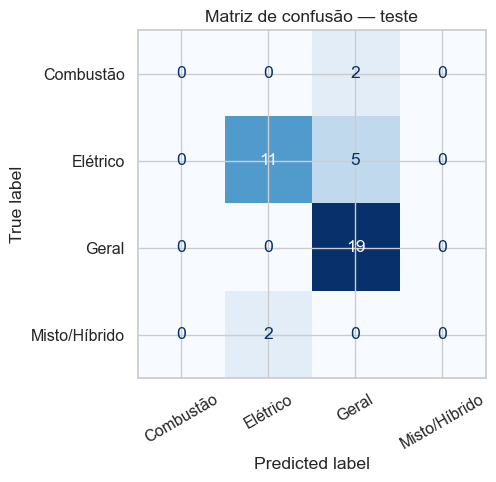

Salvo: fig_confusion_matrix_clean.png


In [30]:
cm = confusion_matrix(y_teste, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=nomes_classes)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
ax.set_title("Matriz de confusão — teste")
plt.tight_layout()
plt.savefig("fig_confusion_matrix_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print("Salvo: fig_confusion_matrix_clean.png")

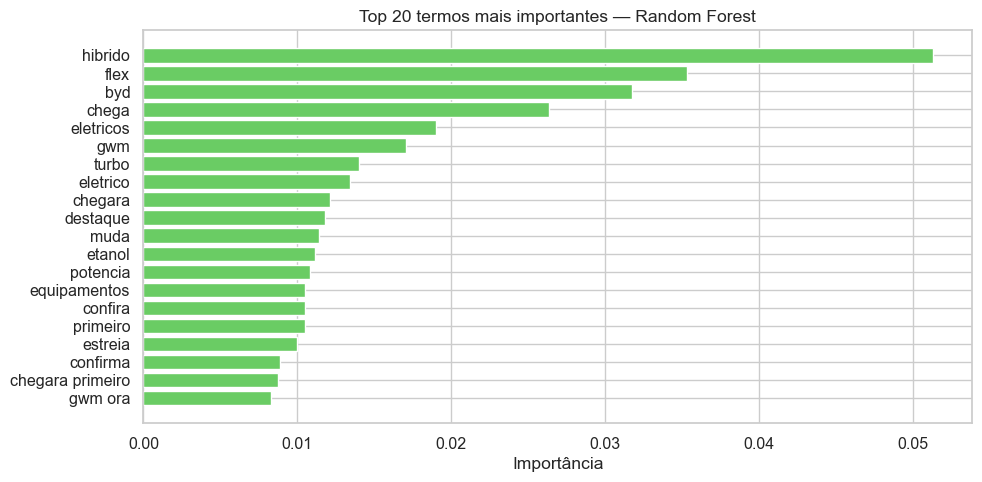

Salvo: fig_feature_importance_clean.png


In [31]:
importancias = pd.Series(clf.feature_importances_, index=vocab)
top_imp = importancias.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color=CORES[2])
ax.set_title("Top 20 termos mais importantes — Random Forest")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.savefig("fig_feature_importance_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print("Salvo: fig_feature_importance_clean.png")

## 11. Regressão — volume lexical

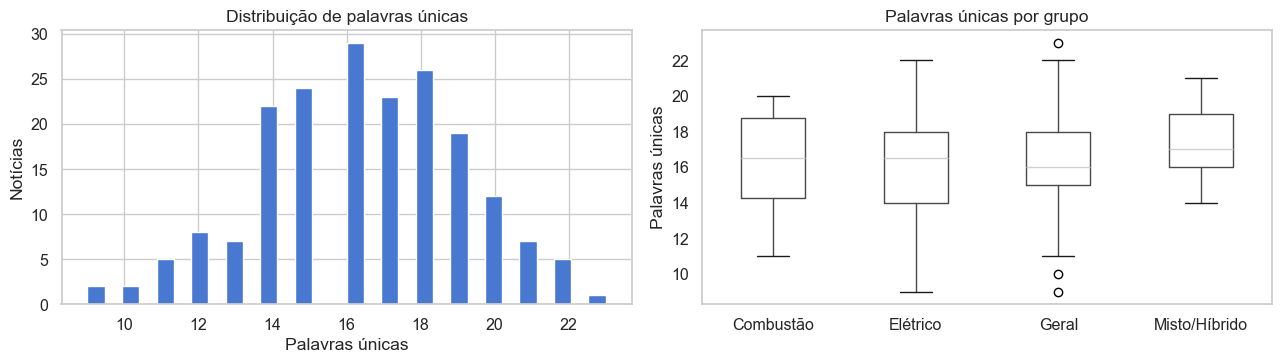

In [32]:
y_reg = df["n_unicos"].values
X_reg = X

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_reg, bins=30, color=CORES[0], edgecolor="white")
axes[0].set_title("Distribuição de palavras únicas")
axes[0].set_xlabel("Palavras únicas")
axes[0].set_ylabel("Notícias")

df.boxplot(column="n_unicos", by="grupo", ax=axes[1], grid=False)
axes[1].set_title("Palavras únicas por grupo")
axes[1].set_xlabel("")
axes[1].set_ylabel("Palavras únicas")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [33]:
X_tmp_r, X_teste_r, y_tmp_r, y_teste_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_treino_r, X_calib_r, y_treino_r, y_calib_r = train_test_split(
    X_tmp_r, y_tmp_r, test_size=0.25, random_state=42
)

ns_reg = [50, 100, 200, 400]
modelos_reg = {}
resultados_reg = []

for n in ns_reg:
    modelo = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_r, y_treino_r)
    mae = mean_absolute_error(y_calib_r, modelo.predict(X_calib_r))
    resultados_reg.append({"n_estimators": n, "MAE_calib": mae})
    modelos_reg[n] = modelo
    print(f"n={n:3d} -> MAE calib = {mae:.2f}")

df_reg = pd.DataFrame(resultados_reg)
melhor_n_reg = int(df_reg.loc[df_reg["MAE_calib"].idxmin(), "n_estimators"])
print(f"Melhor n_estimators: {melhor_n_reg}")

pred_r = modelos_reg[melhor_n_reg].predict(X_teste_r)
mae_teste = mean_absolute_error(y_teste_r, pred_r)
r2_teste = r2_score(y_teste_r, pred_r)

print(f"MAE no teste: {mae_teste:.2f} palavras")
print(f"R² no teste : {r2_teste:.4f}")

n= 50 -> MAE calib = 2.14
n=100 -> MAE calib = 2.19
n=200 -> MAE calib = 2.17
n=400 -> MAE calib = 2.16
Melhor n_estimators: 50
MAE no teste: 2.67 palavras
R² no teste : 0.0084


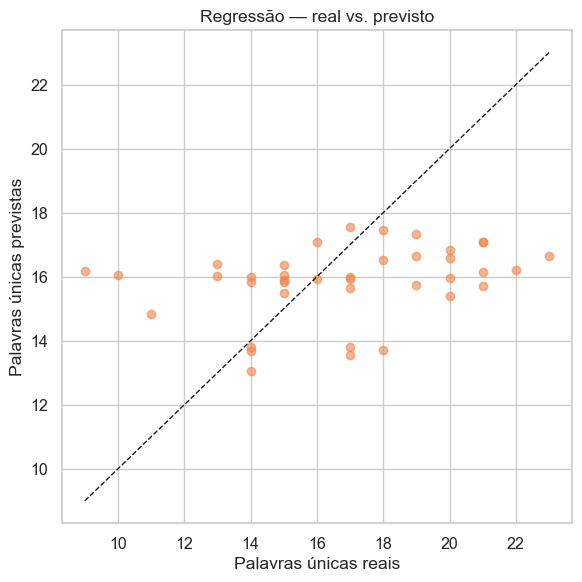

,real,previsto
0,20,16.8
1,20,15.4
2,20,16.6
3,14,13.7
4,19,17.3
5,17,13.8
6,20,16.0
7,15,16.4
8,18,13.7
9,14,15.8


In [34]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_teste_r, pred_r, alpha=0.6, color=CORES[1])

limite_min = min(y_teste_r.min(), pred_r.min())
limite_max = max(y_teste_r.max(), pred_r.max())
ax.plot([limite_min, limite_max], [limite_min, limite_max], "k--", linewidth=1)

ax.set_title("Regressão — real vs. previsto")
ax.set_xlabel("Palavras únicas reais")
ax.set_ylabel("Palavras únicas previstas")
plt.tight_layout()
plt.show()

pd.DataFrame({"real": y_teste_r, "previsto": pred_r.round(1)}).head(10)

## 12. Exportação final

In [35]:
colunas = [
    "url", "titulo", "descricao", "categoria", "data", "grupo",
    "texto_limpo", "n_tokens", "n_unicos",
]

df[colunas].to_csv("motor1_analise_final_clean.csv", index=False, encoding="utf-8-sig")
df_tfidf.to_csv("tfidf_final_clean.csv", index=False, encoding="utf-8-sig")

sumario = df.groupby("grupo").agg(
    n_noticias=("titulo", "count"),
    media_tokens=("n_tokens", "mean"),
    media_unicos=("n_unicos", "mean"),
    mediana_tokens=("n_tokens", "median"),
).round(1)
sumario.to_csv("sumario_grupos_clean.csv", encoding="utf-8-sig")

print("Arquivos exportados:")
print("  motor1_analise_final_clean.csv")
print("  tfidf_final_clean.csv")
print("  sumario_grupos_clean.csv")
print()
print(sumario)

Arquivos exportados:
  motor1_analise_final_clean.csv
  tfidf_final_clean.csv
  sumario_grupos_clean.csv

               n_noticias  media_tokens  media_unicos  mediana_tokens
grupo                                                                
Combustão              10          17.5          16.1            18.0
Elétrico               76          18.7          16.2            18.5
Geral                  95          19.0          16.5            19.0
Misto/Híbrido          11          19.9          17.3            21.0


## 13. Conclusões

Preencha após rodar o notebook:

| Métrica | Valor |
|---|---|
| Total de notícias | |
| Grupo mais frequente | |
| Classificador — acurácia | |
| Classificador — F1 macro | |
| Regressão — MAE | |
| Regressão — R² | |

Pontos para interpretar:

- Os grupos formam clusters visíveis no t-SNE?
- Quais termos diferenciam notícias sobre elétricos, combustão e híbridos?
- Qual grupo tem maior volume lexical médio?
- Quais marcas aparecem mais nas notícias coletadas?

In [36]:
# Unifica classes com poucas amostras
df["grupo3"] = df["grupo"].replace({"Misto/Híbrido": "Combustão/Híbrido", "Combustão": "Combustão/Híbrido"})

print("Distribuição das 3 classes:")
print(df["grupo3"].value_counts())

le3 = LabelEncoder()
y3 = le3.fit_transform(df["grupo3"])
X3 = X_tfidf.toarray()

# Remove classes com menos de 5 amostras (segurança)
contagem_y3 = np.bincount(y3)
classes_validas3 = np.where(contagem_y3 >= 5)[0]
mask3 = np.isin(y3, classes_validas3)
X3_v, y3_v = X3[mask3], y3[mask3]

X3_tmp, X3_teste, y3_tmp, y3_teste = train_test_split(
    X3_v, y3_v, test_size=0.2, random_state=42, stratify=y3_v
)
X3_treino, X3_calib, y3_treino, y3_calib = train_test_split(
    X3_tmp, y3_tmp, test_size=0.25, random_state=42, stratify=y3_tmp
)
print(f"\nTreino: {len(X3_treino)} | Calibração: {len(X3_calib)} | Teste: {len(X3_teste)}")


Distribuição das 3 classes:
grupo3
Geral                95
Elétrico             76
Combustão/Híbrido    21
Name: count, dtype: int64

Treino: 114 | Calibração: 39 | Teste: 39


In [37]:
ns3 = [50, 100, 200, 300, 500]
res3 = []
for n in ns3:
    m = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1, class_weight="balanced")
    m.fit(X3_treino, y3_treino)
    f1_c = f1_score(y3_calib, m.predict(X3_calib), average="macro", zero_division=0)
    res3.append({"n_estimators": n, "F1_macro_calib": f1_c})
    print(f"n={n:3d} -> F1-macro calib = {f1_c:.4f}")

df3_calib = pd.DataFrame(res3)
melhor_n3 = int(df3_calib.loc[df3_calib["F1_macro_calib"].idxmax(), "n_estimators"])
print(f"\nMelhor n_estimators: {melhor_n3}")

clf3 = RandomForestClassifier(n_estimators=melhor_n3, random_state=42, n_jobs=-1, class_weight="balanced")
clf3.fit(X3_treino, y3_treino)
y3_pred = clf3.predict(X3_teste)

nomes3 = le3.classes_[[c for c in np.unique(y3_v)]]
print("\nMétricas no conjunto de teste")
print(f"Acurácia : {accuracy_score(y3_teste, y3_pred):.4f}")
print(f"F1 Macro : {f1_score(y3_teste, y3_pred, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y3_teste, y3_pred, target_names=nomes3, zero_division=0))


n= 50 -> F1-macro calib = 0.5135
n=100 -> F1-macro calib = 0.5135
n=200 -> F1-macro calib = 0.4917
n=300 -> F1-macro calib = 0.5306
n=500 -> F1-macro calib = 0.5344

Melhor n_estimators: 500

Métricas no conjunto de teste
Acurácia : 0.7179
F1 Macro : 0.6106

                   precision    recall  f1-score   support

Combustão/Híbrido       1.00      0.25      0.40         4
         Elétrico       0.89      0.50      0.64        16
            Geral       0.66      1.00      0.79        19

         accuracy                           0.72        39
        macro avg       0.85      0.58      0.61        39
     weighted avg       0.79      0.72      0.69        39



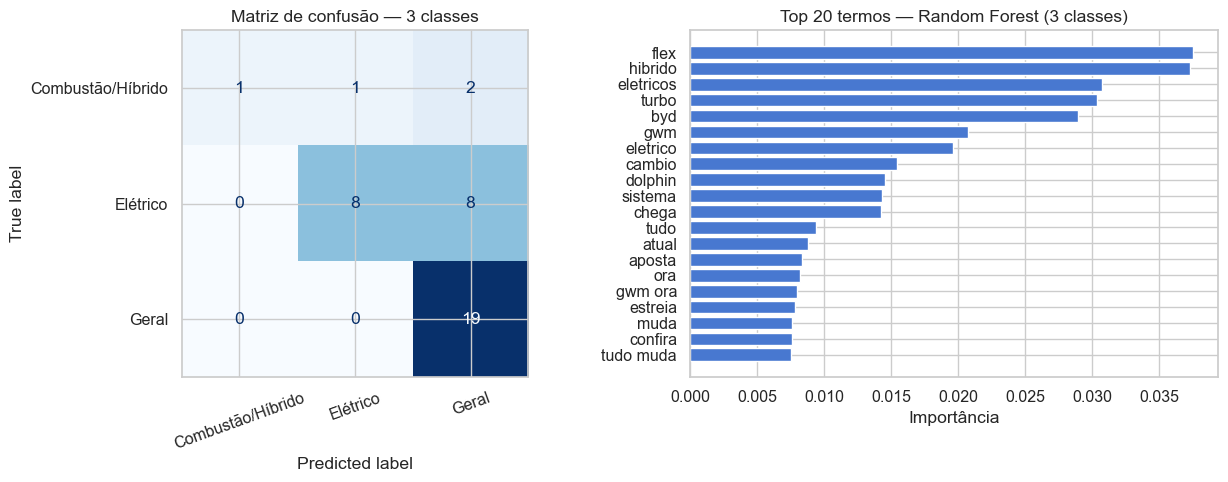

Salvo: fig_clf3_classes.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusão
cm3 = confusion_matrix(y3_teste, y3_pred)
ConfusionMatrixDisplay(cm3, display_labels=nomes3).plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=20)
axes[0].set_title("Matriz de confusão — 3 classes")

# Feature importance
imp3 = pd.Series(clf3.feature_importances_, index=vocab).sort_values(ascending=False).head(20)
axes[1].barh(imp3.index[::-1], imp3.values[::-1], color=sns.color_palette("muted")[0])
axes[1].set_title("Top 20 termos — Random Forest (3 classes)")
axes[1].set_xlabel("Importância")

plt.tight_layout()
plt.savefig("fig_clf3_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig_clf3_classes.png")


In [39]:
from sklearn.metrics.pairwise import cosine_similarity

# Matriz de similaridade (amostras x amostras)
sim_matrix = cosine_similarity(X_tfidf)
np.fill_diagonal(sim_matrix, 0)  # remove auto-similaridade

print(f"Matriz de similaridade: {sim_matrix.shape}")
print(f"Similaridade média entre notícias: {sim_matrix.mean():.4f}")
print(f"Similaridade máxima: {sim_matrix.max():.4f}")


Matriz de similaridade: (192, 192)
Similaridade média entre notícias: 0.0227
Similaridade máxima: 0.7293


In [40]:
# Top 10 pares mais similares
idx = np.unravel_index(np.argsort(sim_matrix, axis=None)[::-1], sim_matrix.shape)
pares_vistos = set()
pares = []
for i, j in zip(idx[0], idx[1]):
    par = (min(i,j), max(i,j))
    if par not in pares_vistos:
        pares_vistos.add(par)
        pares.append({"noticia_A": df.loc[i, "titulo"][:60], "noticia_B": df.loc[j, "titulo"][:60], "similaridade": round(sim_matrix[i,j], 4)})
    if len(pares) == 10:
        break

pd.DataFrame(pares)


,noticia_A,noticia_B,similaridade
0,"Motos em abril: Honda lidera, mas Bajaj chega ...",Motos em abril: Honda CG lidera e Mottu quase ...,0.7293
1,Omoda & Jaecoo quer produzir no Brasil em 2027...,"Com Omoda 4 e Jaecoo 5, marca da Chery terá SU...",0.7074
2,VW Tukan perde camuflagem antes de aparecer na...,Nova VW Tukan aparece na convocação da Seleção...,0.6117
3,BYD Dolphin Mini e Geely EX2 lideraram vendas ...,Resposta aos chineses? Fiat anuncia planos do ...,0.5931
4,Nova VW Tukan aparece na convocação da Seleção...,Nova Tukan? VW do Brasil faz suspense e apaga ...,0.5749
5,"Com Omoda 4 e Jaecoo 5, marca da Chery terá SU...",Omoda & Jaecoo terá híbrido flex já em 2027; 1...,0.5613
6,"Fiat revela os futuros Pulse e Fastback, que t...","Além do Argo: Fiat terá novos Fastback, Pulse,...",0.5555
7,IPVA por quilo? Conheça a proposta que quer li...,Vai mudar? PEC do IPVA por quilo será analisad...,0.5509
8,Jaecoo 7 Elite chega por R$ 179.990 e vira SUV...,"Jaecoo 7 Elite, versão mais barata do SUV híbr...",0.5355
9,Novo Audi Q6 e-Tron 2026 está mais potente e p...,"Audi A5 2026 corrige falhas, ganha mais equipa...",0.5290


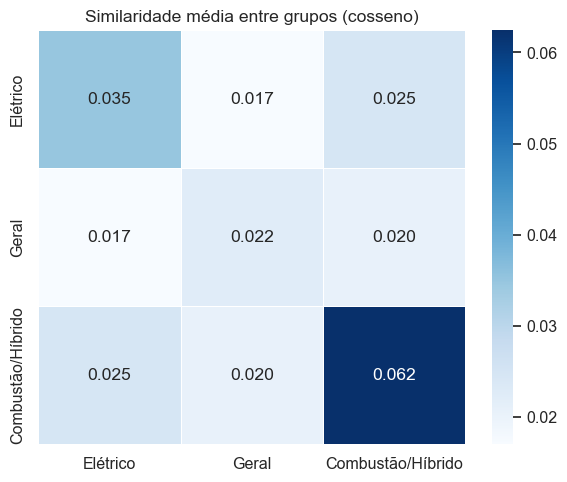

Salvo: fig_similaridade_grupos.png


In [41]:
# Heatmap de similaridade média por grupo
grupos_uniq = df["grupo3"].unique()
n_g = len(grupos_uniq)
grupo_idx = {g: df[df["grupo3"] == g].index.tolist() for g in grupos_uniq}

sim_grupos = pd.DataFrame(index=grupos_uniq, columns=grupos_uniq, dtype=float)
for g1 in grupos_uniq:
    for g2 in grupos_uniq:
        bloco = sim_matrix[np.ix_(grupo_idx[g1], grupo_idx[g2])]
        sim_grupos.loc[g1, g2] = bloco.mean()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(sim_grupos.astype(float), annot=True, fmt=".3f", cmap="Blues", ax=ax, linewidths=0.5)
ax.set_title("Similaridade média entre grupos (cosseno)")
plt.tight_layout()
plt.savefig("fig_similaridade_grupos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig_similaridade_grupos.png")


Vocabulário após filtro: 512 termos
Documentos no corpus: (192, 512)

Coerência por tópico (top 10 termos):

Tópico 1: 9.685*"chega" + 8.214*"bmw" + 7.205*"confira" + 6.206*"hibrido" + 5.200*"mercedes" + 5.087*"eletrico" + 5.074*"suvs" + 4.691*"detalhes" + 4.210*"apenas" + 4.205*"novos"

Tópico 2: 14.190*"suv" + 10.210*"abril" + 9.226*"chevrolet" + 9.201*"dolphin" + 8.151*"strada" + 7.855*"fiat" + 6.979*"byd" + 6.204*"jaecoo" + 6.203*"tukan" + 6.201*"geely"

Tópico 3: 17.199*"gwm" + 17.076*"suv" + 15.919*"hibrido" + 15.645*"chega" + 15.212*"flex" + 15.197*"honda" + 11.992*"fiat" + 9.837*"eletrico" + 9.200*"ora" + 9.110*"sistema"

Tópico 4: 20.258*"byd" + 16.661*"eletricos" + 11.204*"hibridos" + 9.213*"jeep" + 9.198*"dolphin" + 7.199*"geely" + 6.205*"china" + 6.204*"mil" + 6.203*"omoda" + 6.203*"jaecoo"

Tópico 5: 14.288*"suv" + 11.202*"serie" + 8.941*"estreia" + 7.080*"picape" + 6.940*"jeep" + 6.199*"ram" + 5.871*"antes" + 5.411*"avenger" + 5.205*"lotus" + 5.203*"omoda"


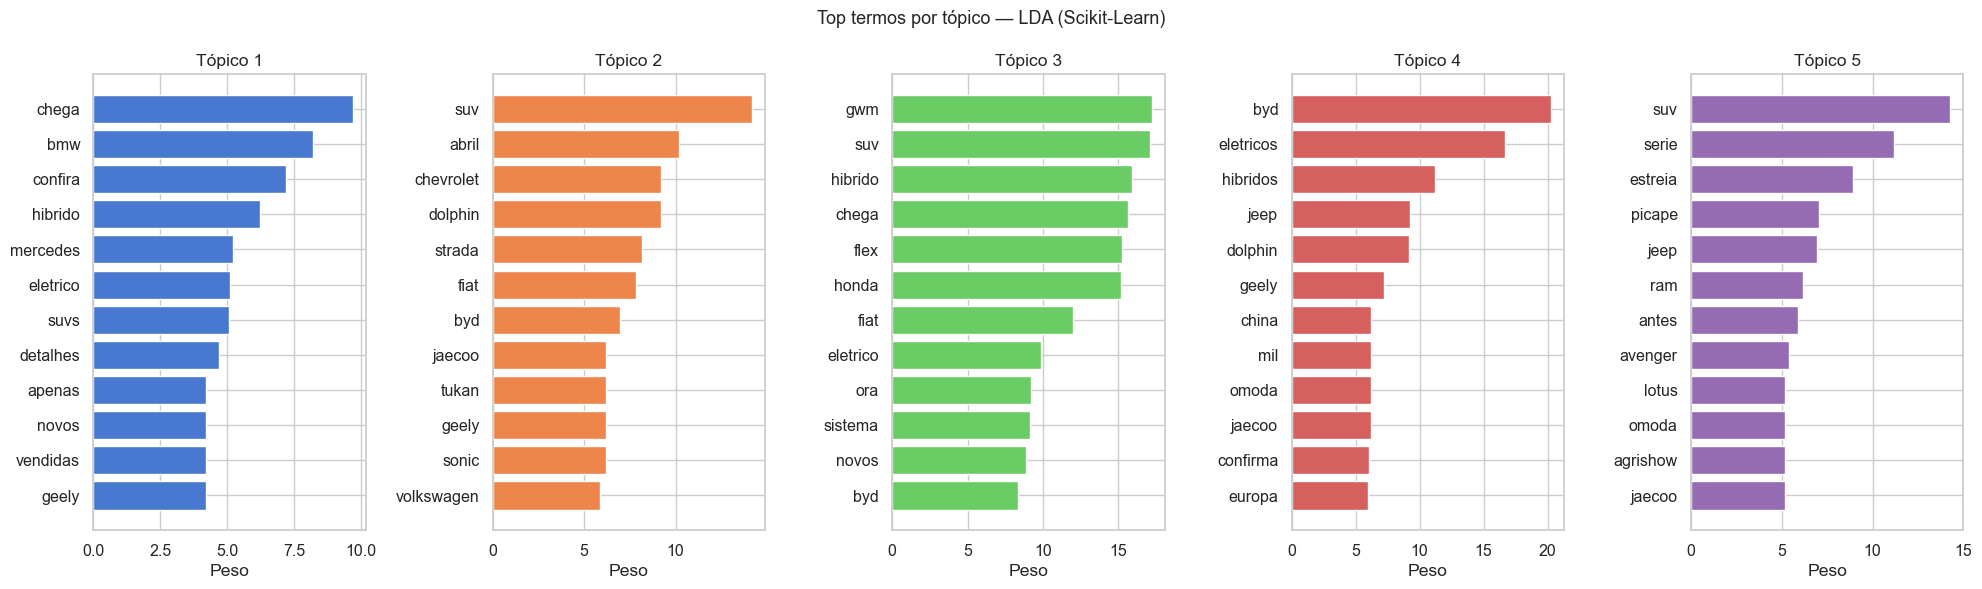

Salvo: fig_lda_topicos.png

Distribuição de notícias por tópico LDA:
topico_lda
1    31
2    33
3    59
4    37
5    32
Name: count, dtype: int64

Cruzamento Tópico LDA vs grupo3:


grupo3,Combustão/Híbrido,Elétrico,Geral,All
topico_lda,,,,
1,2,12,17,31
2,2,13,18,33
3,14,22,23,59
4,1,21,15,37
5,2,8,22,32
All,21,76,95,192


In [47]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")

# 1. Prepara o corpus usando o CountVectorizer do sklearn (Equivalente ao Dictionary do Gensim)
vectorizer = CountVectorizer(min_df=2, max_df=0.85)
bow_corpus = vectorizer.fit_transform(df["texto_limpo"])
nomes_termos = vectorizer.get_feature_names_out()

print(f"Vocabulário após filtro: {len(nomes_termos)} termos")
print(f"Documentos no corpus: {bow_corpus.shape}")

N_TOPICOS = 5

# 2. Treina o modelo LDA do Scikit-Learn
lda_model = LatentDirichletAllocation(
    n_components=N_TOPICOS,
    random_state=42,
    max_iter=15,  # Equivalente ao 'passes' do Gensim
)
lda_model.fit(bow_corpus)

print("\nCoerência por tópico (top 10 termos):")
# Matriz de componentes (tópicos x termos)
componentes = lda_model.components_

for i, topico in enumerate(componentes):
    # Pega os índices dos 10 termos com maior peso
    top_indices = topico.argsort()[:-11:-1]
    termos_formatados = " + ".join(
        [f'{topico[idx]:.3f}*"{nomes_termos[idx]}"' for idx in top_indices]
    )
    print(f"\nTópico {i+1}: {termos_formatados}")


# 3. Visualização: barras horizontais com os top termos por tópico
fig, axes = plt.subplots(1, N_TOPICOS, figsize=(4 * N_TOPICOS, 6), squeeze=False)
cores_lda = sns.color_palette("muted", N_TOPICOS)

for i, ax in enumerate(axes.ravel()):
    topico = componentes[i]
    # Pega os 12 termos mais importantes
    top_indices = topico.argsort()[:-13:-1][::-1]

    palavras = [nomes_termos[idx] for idx in top_indices]
    pesos = [topico[idx] for idx in top_indices]

    ax.barh(palavras, pesos, color=cores_lda[i])
    ax.set_title(f"Tópico {i+1}")
    ax.set_xlabel("Peso")

plt.suptitle("Top termos por tópico — LDA (Scikit-Learn)", fontsize=13)
plt.tight_layout()
plt.savefig("fig_lda_topicos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig_lda_topicos.png")


# 4. Atribui o tópico dominante a cada notícia
# lda_model.transform nos dá a distribuição de tópicos para cada linha do texto
distribuicao_topicos = lda_model.transform(bow_corpus)

# argmax encontra o índice do tópico com maior probabilidade (somamos 1 para ficar de 1 a 5)
df["topico_lda"] = distribuicao_topicos.argmax(axis=1) + 1

print("\nDistribuição de notícias por tópico LDA:")
print(df["topico_lda"].value_counts().sort_index())
print()

# 5. Cruza tópico LDA com grupo temático
# Nota: certifique-se que a coluna 'grupo3' ou 'grupo' existe no seu df (ajuste o nome se necessário)
coluna_grupo = "grupo3" if "grupo3" in df.columns else "grupo"
print(f"Cruzamento Tópico LDA vs {coluna_grupo}:")
display(pd.crosstab(df["topico_lda"], df[coluna_grupo], margins=True))

In [48]:
colunas = [
    "url", "titulo", "descricao", "categoria", "data", "grupo", "grupo3",
    "texto_limpo", "n_tokens", "n_unicos", "topico_lda",
]

df[colunas].to_csv("motor1_analise_final_clean.csv", index=False, encoding="utf-8-sig")

sumario = df.groupby("grupo3").agg(
    n_noticias=("titulo", "count"),
    media_tokens=("n_tokens", "mean"),
    media_unicos=("n_unicos", "mean"),
    mediana_tokens=("n_tokens", "median"),
).round(1)
sumario.to_csv("sumario_grupos_clean.csv", encoding="utf-8-sig")

print("Arquivos exportados:")
print("  motor1_analise_final_clean.csv")
print("  sumario_grupos_clean.csv")
print()
print(sumario)


Arquivos exportados:
  motor1_analise_final_clean.csv
  sumario_grupos_clean.csv

                   n_noticias  media_tokens  media_unicos  mediana_tokens
grupo3                                                                   
Combustão/Híbrido          21          18.8          16.7            19.0
Elétrico                   76          18.7          16.2            18.5
Geral                      95          19.0          16.5            19.0


Text(0.5, 0, '')

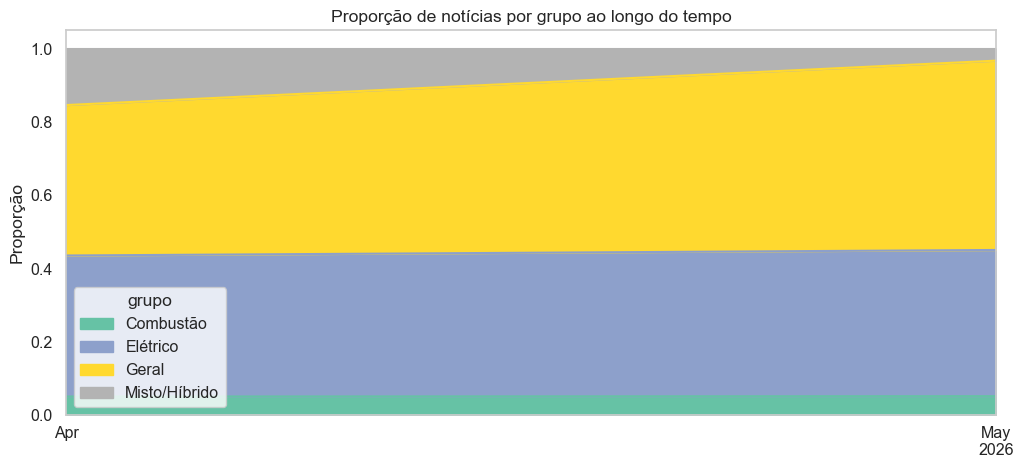

In [49]:
df['ano_mes'] = pd.to_datetime(df['data'], errors='coerce').dt.to_period('M')

# Proporção de cada grupo por mês
contagem = df.groupby(['ano_mes', 'grupo']).size().unstack(fill_value=0)
proporcao = contagem.div(contagem.sum(axis=1), axis=0)

# Area chart empilhado
proporcao.plot(kind='area', stacked=True, figsize=(12, 5), colormap='Set2')
plt.title('Proporção de notícias por grupo ao longo do tempo')
plt.ylabel('Proporção')
plt.xlabel('')

In [50]:
MARCAS = ["byd", "tesla", "toyota", "volkswagen", "chevrolet",
          "fiat", "honda", "hyundai", "gwm", "haval", "leapmotor"]

rows = []
for _, row in df.iterrows():
    toks = set(row['tokens']) if isinstance(row['tokens'], list) else set()
    for marca in MARCAS:
        if marca in toks:
            rows.append({'marca': marca.upper(), 'grupo': row['grupo']})

df_marcas = pd.DataFrame(rows)

# Heatmap marca x grupo
pivot = df_marcas.groupby(['marca','grupo']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Presença de marcas por grupo temático')

KeyError: 'tokens'

Text(0.5, 1.0, 'Tamanho das notícias por grupo (em tokens)')

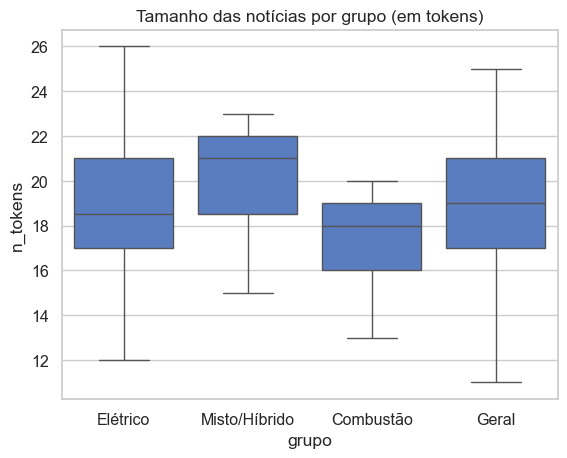

In [51]:
sns.boxplot(data=df, x='grupo', y='n_tokens', order=['Elétrico','Misto/Híbrido','Combustão','Geral'])
plt.title('Tamanho das notícias por grupo (em tokens)')

In [53]:
# Média TF-IDF por grupo, mostra os termos com maior diferença
tfidf_eletrico = df_tfidf[df['grupo'] == 'Elétrico'].mean()
tfidf_combustao = df_tfidf[df['grupo'] == 'Combustão'].mean()
diferenca = (tfidf_eletrico - tfidf_combustao).sort_values(ascending=False)

# Top 15 "mais elétrico" vs top 15 "mais combustão"

In [54]:
# Exemplos de erro — os mais interessantes
df_teste_com_titulos = df.iloc[indices_teste].copy()
df_teste_com_titulos['previsto'] = le.inverse_transform(y_pred)
df_teste_com_titulos['real'] = le.inverse_transform(y_teste)

erros = df_teste_com_titulos[df_teste_com_titulos['real'] != df_teste_com_titulos['previsto']]
print(erros[['titulo', 'real', 'previsto']].head(5))

NameError: name 'indices_teste' is not defined